In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [4]:
# Define classifiers and their parameter grids
classifiers = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_jobs=-1),
    "SVM": SVC(probability=True)
}

param_grids = {
    "KNN": {"n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"]},
    "Logistic Regression": {"C": [0.1, 1, 10],
                           "penalty": ["l2"]},
    "Decision Tree": {"max_depth": [3, 5, 7],
                     "min_samples_split": [2, 5]},
    "Random Forest": {"n_estimators": [100, 200],
                     "max_depth": [3, 5, 7],
                     "min_samples_split": [2, 5]},
    "SVM": {"C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]}
}

In [5]:

results = {}


for name, classifier in classifiers.items():
    
    start_time = time.time()
    grid_search = GridSearchCV(classifier, param_grids[name], cv=5, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    y_pred = grid_search.predict(X_test)
    
    # Store results
    results[name] = {
        "Best Parameters": grid_search.best_params_,
        "Training Time": training_time,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Best CV Score": grid_search.best_score_,
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred)
    }


In [6]:
# Print results
print("\nResults Summary:")
print("-" * 50)
for name, result in results.items():
    print(f"\n{name}:")
    print(f"Best Parameters: {result['Best Parameters']}")
    print(f"Training Time: {result['Training Time']:.2f} seconds")
    print(f"Test Accuracy: {result['Test Accuracy']:.4f}")
    print(f"Best CV Score: {result['Best CV Score']:.4f}")
    print("\nClassification Report:")
    print(result['Classification Report'])
    print("-" * 50)


Results Summary:
--------------------------------------------------

KNN:
Best Parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Training Time: 5.10 seconds
Test Accuracy: 0.9591
Best CV Score: 0.9598

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

--------------------------------------------------

Logistic Regression:
Best Parameters: {'C': 1, 'penalty': 'l2'}
Training Time: 0.07 seconds
Test Accuracy: 0.9825
Best CV Score: 0.9748

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg  

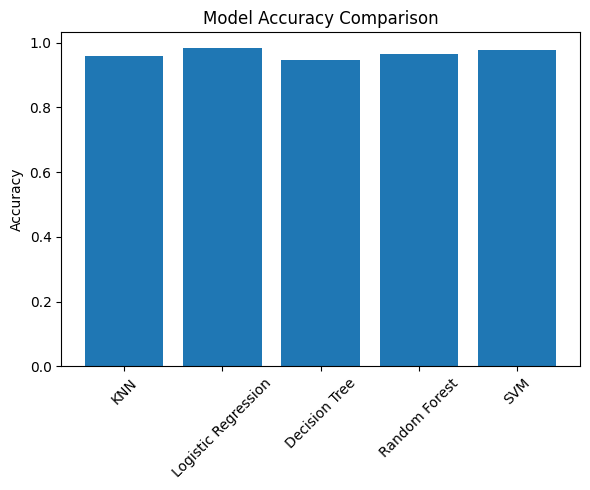

In [7]:
# Visualization

plt.figure(figsize=(6, 5))
accuracies = [result['Test Accuracy'] for result in results.values()]
plt.bar(results.keys(), accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

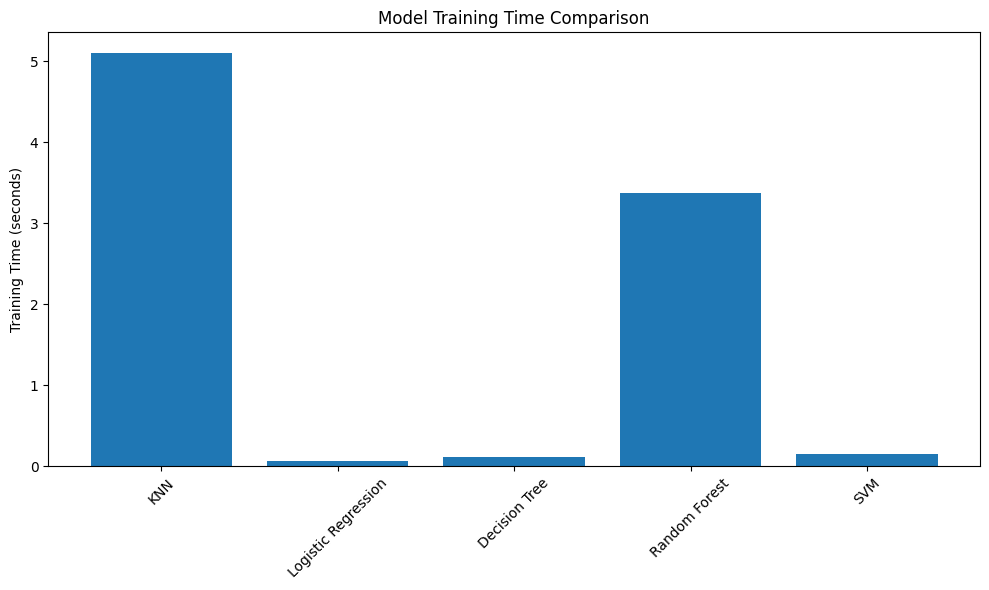

In [8]:
# Training Time Comparison
plt.figure(figsize=(10, 6))
times = [result['Training Time'] for result in results.values()]
plt.bar(results.keys(), times)
plt.title('Model Training Time Comparison')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

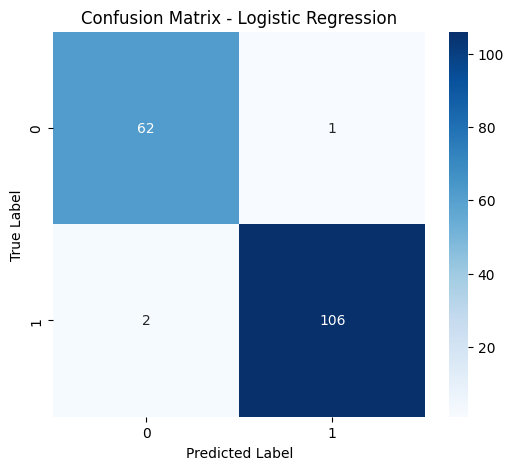

In [9]:
# Confusion Matrix for the best model
best_model = max(results.items(), key=lambda x: x[1]['Test Accuracy'])
plt.figure(figsize=(6, 5))
sns.heatmap(best_model[1]['Confusion Matrix'], annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model[0]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [10]:
#best performing model
print(f"\nBest Performing Model: {best_model[0]}")
print(f"Accuracy: {best_model[1]['Test Accuracy']:.4f}")


Best Performing Model: Logistic Regression
Accuracy: 0.9825
